In [1]:
import os
import pandas as pd
import numpy as np
from feedbackFunctions import get_paths, extract_timeseries, read_events, execute

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_dir = os.path.join(data_dir,'derivatives','fmriprep23','fmriprep')
nilearn_dir = os.path.join(data_dir,'derivatives','nilearn_glm')
output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['AA','UA']
hrf_delay = 4 # in seconds

In [3]:
# Load subject-specific roi coordinates
roi_ss_coords = pd.read_csv(os.path.join(nilearn_dir,'group','roi_ss_matrix.txt'), sep='\t', header=None,
                            names=['left_x','left_y','left_z','right_x','right_y','right_z'])

# add new column with the subject names
roi_ss_coords['subject'] = subject_list
labels = ['hMT+ L', 'hMT+ R']

In [4]:
# Initialize matrix to store the timeseries of all subjects per tr
TC = np.zeros((len(subject_list), len(tr_list), len(run_list), max(n_volumes_list)))


In [4]:
# Create combinations of subject, tr and run
C = []
for ss,subject in enumerate(subject_list):
    # extract x,y,z coordinates of this subject's hMT+ roi
    cluster_coords = [[0, 0, 0], [0, 0, 0]]
    cluster_coords[0] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,0:3].values[0].tolist()
    cluster_coords[1] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,3:6].values[0].tolist()

    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            C.append([ss,subject, tt,tr, rr,run, cluster_coords, hrf_delay, fmriprep_dir, data_dir])

C

[[0,
  'sub-01',
  0,
  0.5,
  0,
  'AA',
  [[-46, -70, 12], [46, -76, 6]],
  4,
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 [0,
  'sub-01',
  0,
  0.5,
  1,
  'UA',
  [[-46, -70, 12], [46, -76, 6]],
  4,
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 [0,
  'sub-01',
  1,
  0.75,
  0,
  'AA',
  [[-46, -70, 12], [46, -76, 6]],
  4,
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 [0,
  'sub-01',
  1,
  0.75,
  1,
  'UA',
  [[-46, -70, 12], [46, -76, 6]],
  4,
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 [0,
  'sub-01',
  2,
  1,
  0,
  'AA',
  [[-46, -70, 12], [46, -76, 6]],
  4,
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep',
  '/DATAPOOL/VPMB/BIDS-VPMB-SPE'],
 [0,
  'sub-01',
  2,
  1,
  1,
  'UA',
  [[-46, -70, 12], [46, -76, 6]],
  4,
  '/DATAPOO

In [5]:
from multiprocessing import Pool
pool = Pool(20)

results = pool.starmap(execute,C)
pool.close()

sub-01_0.75_AAsub-01_1_AAsub-01_2.5_AAsub-02_1_AAsub-01_0.5_AAsub-02_2.5_AAsub-02_0.75_AAsub-02_0.5_AAsub-03_0.5_AAsub-03_0.75_AAsub-03_1_AAsub-03_2.5_AAsub-05_0.5_AAsub-05_0.75_AAsub-05_1_AA
sub-05_2.5_AAsub-06_0.5_AA
sub-06_0.75_AAsub-06_1_AAsub-06_2.5_AA



















/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


sub-05_2.5_UA


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


sub-06_2.5_UA


...

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return

sub-23_0.5_UA


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return

sub-22_0.5_UA


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return

In [39]:
# create dataframe based on results
df = pd.DataFrame(results)

df['subject'] = [x[1] for x in C]
df['tr'] = [x[3] for x in C]
df['run'] = [x[5] for x in C]

df.to_csv(os.path.join(output_dir,'feedbackSimulator.tsv'), index=False, sep='\t')
#df.iloc[:,0:10].mean(axis=0)


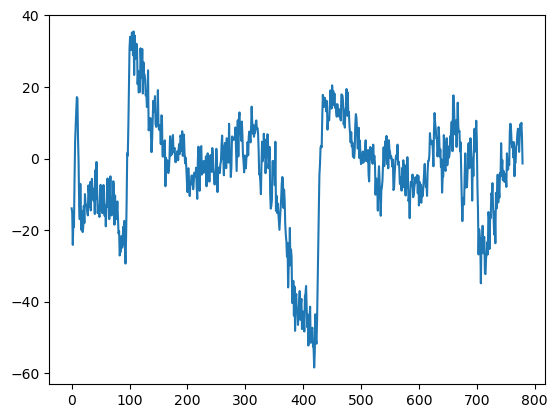

In [41]:
# fetch data for tr=0.5
df[df['tr']==0.5].iloc[:,0:780]

# plot timeseries for tr=0.5
import matplotlib.pyplot as plt
plt.plot(df[df['tr']==0.5].iloc[:,0:780].mean(axis=0))
plt.show()